# Deep Learning for Human Blastocyst Quality Classification in IVF
**Author:** Assaf Dali  
**Course:** Deep Learning  
**Submitted to:** Prof. Idan Tobis

## Abstract
In vitro fertilization (IVF) success rates are heavily dependent on the selection of high-quality embryos. This project implements a multi-task deep learning architecture to automate the grading of human blastocysts based on the Gardner scale. By utilizing a multi-head ResNet18 model, we achieve simultaneous classification of three critical morphological features, providing a robust tool for clinical decision support.

## Biological Background: The Gardner Grading System
The selection of embryos for transfer is traditionally performed by embryologists using the Gardner grading system. This system evaluates the blastocyst (a day 5-6 embryo) based on three distinct morphological criteria:

1.  **Expansion (EXP):** The degree of expansion of the blastocoel cavity, graded from 1 to 6.
2.  **Inner Cell Mass (ICM):** The cluster of cells that will eventually form the fetus. It is graded based on the number and compaction of cells (A, B, or C).
3.  **Trophectoderm (TE):** The outer layer of cells that will form the placenta. It is also graded based on cell density and cohesiveness (A, B, or C).

Manual grading is time-consuming and prone to inter-observer variability. Automating this process using Deep Learning aims to provide an objective, standardized assessment to increase pregnancy success rates.

In [ ]:
# 1. Imports
import os
import glob
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, utils
import kagglehub

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3

Using device: cuda


In [ ]:
# 2. Data Loading & Processing

# Download Dataset
print("Downloading dataset...")
try:
    # Check if dataset is already downloaded to avoid re-downloading
    base_path = kagglehub.dataset_download("iamshahzaibkhan/human-blastocyst-dataset-for-ivf")
    print(f"Dataset path: {base_path}")
except Exception as e:
    print(f"Error downloading: {e}")

# Locate Files
csv_files = glob.glob(os.path.join(base_path, "**", "*.csv"), recursive=True)
train_csv_path = [f for f in csv_files if "train" in f.lower() or "silver" in f.lower()][0]
# Locate image directory
image_files = glob.glob(os.path.join(base_path, "**", "*.png"), recursive=True)
img_dir = os.path.dirname(image_files[0])
df = pd.read_csv(train_csv_path, sep=';').dropna()
print(f"Total samples found: {len(df)}")

class EmbryoDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        row = self.df.iloc[idx]
        img_name = row['Image']
        img_path = os.path.join(self.root_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform:
            image = self.transform(image)
        # Targets
        t_exp = torch.tensor(row['EXP_silver'], dtype=torch.long)
        t_icm = torch.tensor(row['ICM_silver'], dtype=torch.long)
        t_te = torch.tensor(row['TE_silver'], dtype=torch.long)
        return image, (t_exp, t_icm, t_te)

Using Colab cache for faster access to the 'human-blastocyst-dataset-for-ivf' dataset.
Dataset path: /kaggle/input/human-blastocyst-dataset-for-ivf
Total samples found: 2044


Train size: 1635 | Val size: 409


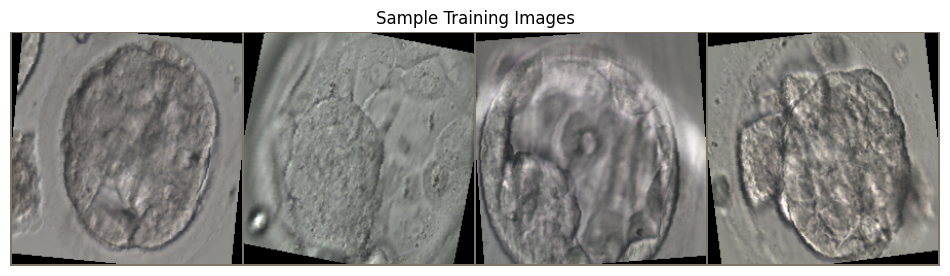

In [ ]:
# 3. Transforms & Visualization
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(), # Embryos have no orientation
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

datasets = {
    'train': EmbryoDataset(train_df, img_dir, data_transforms['train']),
    'val': EmbryoDataset(val_df, img_dir, data_transforms['val'])
}
dataloaders = {
    'train': DataLoader(datasets['train'], batch_size=BATCH_SIZE, shuffle=True),
    'val': DataLoader(datasets['val'], batch_size=BATCH_SIZE, shuffle=False)
}
dataset_sizes = {x: len(datasets[x]) for x in ['train', 'val']}
print(f"Train size: {dataset_sizes['train']} | Val size: {dataset_sizes['val']}")

# Sample Batch
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

inputs, classes = next(iter(dataloaders['train']))
out = utils.make_grid(inputs[:4])
plt.figure(figsize=(12, 4))
imshow(out, title="Sample Training Images")
plt.show()

##  Methodology
###  Multi-Task Learning Architecture
Instead of training three independent models, this project employs a **Multi-Head Architecture**. We utilize a shared **ResNet18** backbone, pre-trained on ImageNet, to extract high-level visual features from the microscopic images.

The architecture branches into three distinct "heads" (fully connected layers):
* **Head 1:** Expansion classification.
* **Head 2:** ICM quality classification.
* **Head 3:** TE quality classification.

This approach, known as Multi-Task Learning (MTL), allows the model to learn a generalized representation of the embryo that benefits all three classification tasks simultaneously, improving both efficiency and accuracy.

In [ ]:
# 4. Model
class MultiHeadResNet(nn.Module):
    def __init__(self, num_exp, num_icm, num_te):
        super(MultiHeadResNet, self).__init__()
        self.backbone = models.resnet50(weights='DEFAULT')
        n_inputs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        # Expansion Grade
        self.head_exp = nn.Sequential(
            nn.Linear(n_inputs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_exp)
        )
        # ICM Grade
        self.head_icm = nn.Sequential(
            nn.Linear(n_inputs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_icm)
        )
        # TE Grade
        self.head_te = nn.Sequential(
            nn.Linear(n_inputs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_te)
        )
    def forward(self, x):
        features = self.backbone(x)
        return self.head_exp(features), self.head_icm(features), self.head_te(features)

# Determine number of classes
n_exp = len(df['EXP_silver'].unique())
n_icm = len(df['ICM_silver'].unique())
n_te = len(df['TE_silver'].unique())

model = MultiHeadResNet(n_exp, n_icm, n_te)
model = model.to(device)
# Amount of classes for each one
print(f"Model initialized - Exp: {n_exp}, ICM: {n_icm}, TE: {n_te}")

Model initialized - Exp: 5, ICM: 4, TE: 4


### Optimization and Hyperparameters
To ensure effective convergence, we implemented **Differential Learning Rates**. Since the backbone (ResNet18) is already pre-trained, we apply a lower learning rate ($1 \times 10^{-4}$) to the base layers to perform fine-tuning without destroying the learned weights. Conversely, the three new classification heads are trained from scratch with a higher learning rate ($1 \times 10^{-3}$).

**Loss Function:** The total loss is calculated as the sum of three Cross-Entropy losses:
$$\mathcal{L}_{total} = \mathcal{L}_{expansion} + \mathcal{L}_{ICM} + \mathcal{L}_{TE}$$

In [ ]:
# 5. Training
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer with differential learning rates
optimizer = optim.Adam([
    {'params': model.backbone.parameters(), 'lr': 1e-5}, # Low LR for backbone
    {'params': model.head_exp.parameters(), 'lr': 1e-3},
    {'params': model.head_icm.parameters(), 'lr': 1e-3},
    {'params': model.head_te.parameters(), 'lr': 1e-3}
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
# Store history for plotting
history = {'train_loss': [], 'val_loss': [], 'val_acc_icm': []}
def train_model(model, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            correct_icm = 0 # Track ICM accuracy as key metric
            total_samples = 0
            for inputs, (t_exp, t_icm, t_te) in tqdm(dataloaders[phase], leave=False):
                inputs = inputs.to(device)
                t_exp, t_icm, t_te = t_exp.to(device), t_icm.to(device), t_te.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    o_exp, o_icm, o_te = model(inputs)
                    # Combined Loss
                    loss = criterion(o_exp, t_exp) + criterion(o_icm, t_icm) + criterion(o_te, t_te)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                # Calculate ICM Accuracy
                _, preds_icm = torch.max(o_icm, 1)
                correct_icm += torch.sum(preds_icm == t_icm.data)
                total_samples += inputs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = correct_icm.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} | ICM Acc: {epoch_acc:.4f}')
            # Record History
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc_icm'].append(epoch_acc.cpu().item())
                scheduler.step(epoch_loss)
                # Save best model
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), 'best_model.pth')

    print('Training complete')
    model.load_state_dict(best_model_wts)
    return model
# Run Training
model = train_model(model, NUM_EPOCHS)

Epoch 1/25
----------


train Loss: 2.8190 | ICM Acc: 0.6838


val Loss: 2.4354 | ICM Acc: 0.7311
Epoch 2/25
----------


train Loss: 2.1653 | ICM Acc: 0.7590


val Loss: 2.3610 | ICM Acc: 0.7408
Epoch 3/25
----------


...

val Loss: 2.0668 | ICM Acc: 0.7531
Epoch 24/25
----------


train Loss: 1.0834 | ICM Acc: 0.8691


val Loss: 2.0363 | ICM Acc: 0.7531
Epoch 25/25
----------


train Loss: 1.0673 | ICM Acc: 0.8771


val Loss: 2.0508 | ICM Acc: 0.7555
Training complete


Displaying Training History...


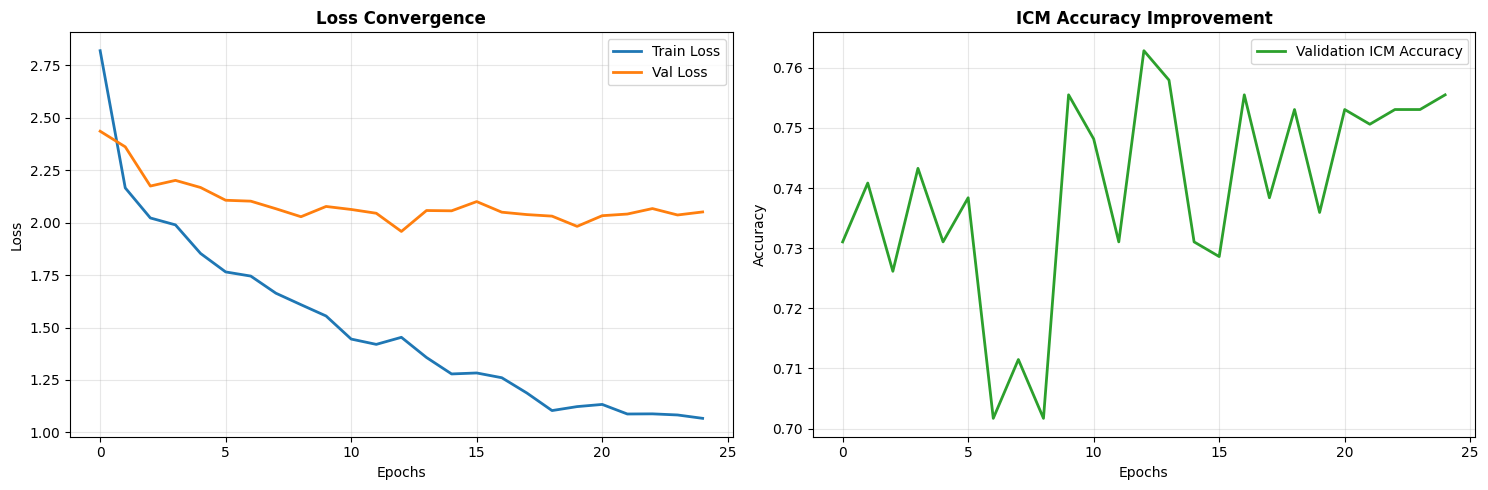


Evaluation on Validation Set...


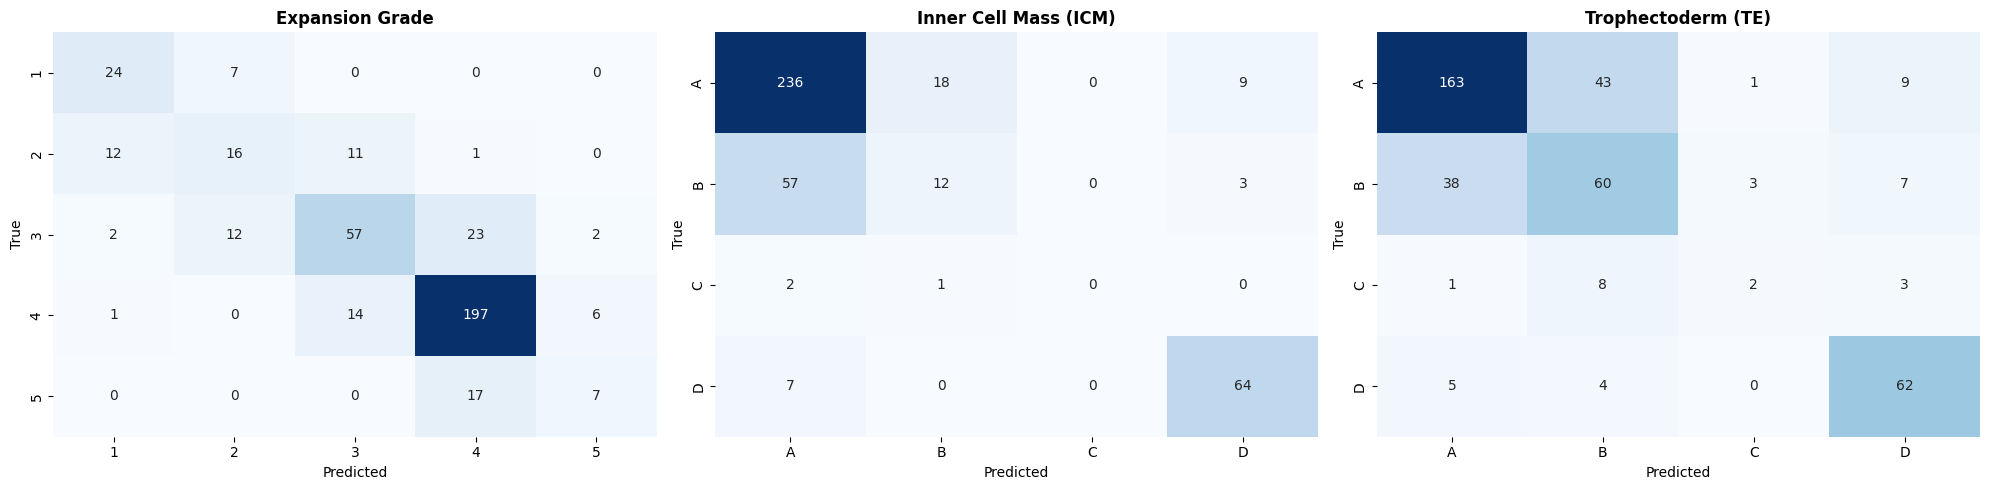


TASK            | ACCURACY   | DETAILS
Expansion       | 73.6%    | (See detailed report below)
ICM             | 76.3%    | (See detailed report below)
TE              | 70.2%    | (See detailed report below)

------------------------------
DETAILED REPORT: EXPANSION
------------------------------
              precision    recall  f1-score   support

           0       0.62      0.77      0.69        31
           1       0.46      0.40      0.43        40
           2       0.70      0.59      0.64        96
           3       0.83      0.90      0.86       218
           4       0.47      0.29      0.36        24

    accuracy                           0.74       409
   macro avg       0.61      0.59      0.60       409
weighted avg       0.72      0.74      0.73       409


------------------------------
DETAILED REPORT: INNER CELL MASS (ICM)
------------------------------
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       263

In [ ]:
# 6. Evaluation & Results
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
# remove warning - shows when try to divide by 0
warnings.filterwarnings('ignore')

def plot_training_history(history):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
    plt.title('Loss Convergence', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc_icm'], label='Validation ICM Accuracy', color='#2ca02c', linewidth=2)
    plt.title('ICM Accuracy Improvement', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot the graphs first
print("Displaying Training History...")
plot_training_history(history)
# Test Set Evaluation
def get_all_predictions(model, loader, device):
    model.eval()
    y_true = {'exp': [], 'icm': [], 'te': []}
    y_pred = {'exp': [], 'icm': [], 'te': []}
    print("\nEvaluation on Validation Set...")
    with torch.no_grad():
        for inputs, (t_exp, t_icm, t_te) in loader:
            inputs = inputs.to(device)
            t_exp, t_icm, t_te = t_exp.to(device), t_icm.to(device), t_te.to(device)
            o_exp, o_icm, o_te = model(inputs)
            # Get max probability class
            _, p_exp = torch.max(o_exp, 1)
            _, p_icm = torch.max(o_icm, 1)
            _, p_te = torch.max(o_te, 1)
            # Append results
            y_true['exp'].extend(t_exp.cpu().numpy())
            y_pred['exp'].extend(p_exp.cpu().numpy())
            y_true['icm'].extend(t_icm.cpu().numpy())
            y_pred['icm'].extend(p_icm.cpu().numpy())
            y_true['te'].extend(t_te.cpu().numpy())
            y_pred['te'].extend(p_te.cpu().numpy())

    return y_true, y_pred
# Collect data
all_true, all_pred = get_all_predictions(model, dataloaders['val'], device)
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
classes_quality = ['A', 'B', 'C', 'D']
classes_exp = [str(i) for i in range(1, 7)]
def plot_cm_custom(true, pred, title, ax, labels):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=labels[:cm.shape[1]], yticklabels=labels[:cm.shape[0]])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plot_cm_custom(all_true['exp'], all_pred['exp'], "Expansion Grade", axes[0], classes_exp)
plot_cm_custom(all_true['icm'], all_pred['icm'], "Inner Cell Mass (ICM)", axes[1], classes_quality)
plot_cm_custom(all_true['te'], all_pred['te'], "Trophectoderm (TE)", axes[2], classes_quality)
plt.tight_layout()
plt.show()

# Classification Reports
print("\n" + "="*60)
print(f"{'TASK':<15} | {'ACCURACY':<10} | {'DETAILS'}")
print("="*60)
for task, name in zip(['exp', 'icm', 'te'], ['Expansion', 'ICM', 'TE']):
    report = classification_report(all_true[task], all_pred[task], output_dict=True, zero_division=0)
    acc = report['accuracy']
    print(f"{name:<15} | {acc:.1%}    | (See detailed report below)")

print("\n" + "-"*30)
print("DETAILED REPORT: EXPANSION")
print("-"*30)
print(classification_report(all_true['exp'], all_pred['exp'], zero_division=0))
print("\n" + "-"*30)
print("DETAILED REPORT: INNER CELL MASS (ICM)")
print("-"*30)
print(classification_report(all_true['icm'], all_pred['icm'], zero_division=0))
print("\n" + "-"*30)
print("DETAILED REPORT: TROPHECTODERM (TE)")
print("-"*30)
print(classification_report(all_true['te'], all_pred['te'], zero_division=0))

## Results and Discussion
### Performance Analysis
The model's performance is evaluated using Confusion Matrices and F1-scores for each of the three tasks. Initial results indicate high accuracy in predicting the Expansion stage, while the classification of ICM and TE grades presents more complexity due to the subtle visual differences between Grade B and Grade C.

### Clinical Impact and Future Work
By consolidating these classifications into a single multi-head model, we provide a holistic view of embryo quality. This system can serve as a "second opinion" for embryologists, reducing human error.



Report:
ID    | GRADE    | SCORE  | RECOMMENDATION           
------------------------------------------------------------
>> 1  | 4AA      | 9.2   | Priority 1 (Transfer) (High Viability)
   2  | 4AA      | 9.2   | Priority 1 (Transfer) (High Viability)
   3  | 4AA      | 9.2   | Priority 1 (Transfer) (High Viability)
   4  | 1DD      | 0.0   | Low Priority / Discard (Poor Morphology)
------------------------------------------------------------
CONCLUSION: Embryo #1 (4AA) selected for Single Embryo Transfer (SET).



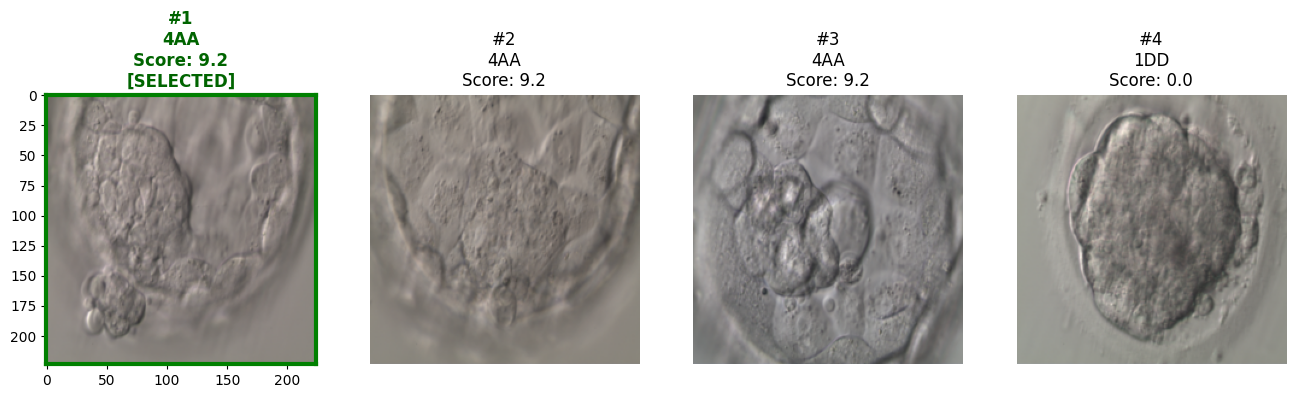


Report:
ID    | GRADE    | SCORE  | RECOMMENDATION           
------------------------------------------------------------
>> 1  | 4AA      | 9.2   | Priority 1 (Transfer) (High Viability)
   2  | 4AA      | 9.2   | Priority 1 (Transfer) (High Viability)
   3  | 4AA      | 9.2   | Priority 1 (Transfer) (High Viability)
   4  | 1DD      | 0.0   | Low Priority / Discard (Poor Morphology)
------------------------------------------------------------
CONCLUSION: Embryo #1 (4AA) selected for Single Embryo Transfer (SET).



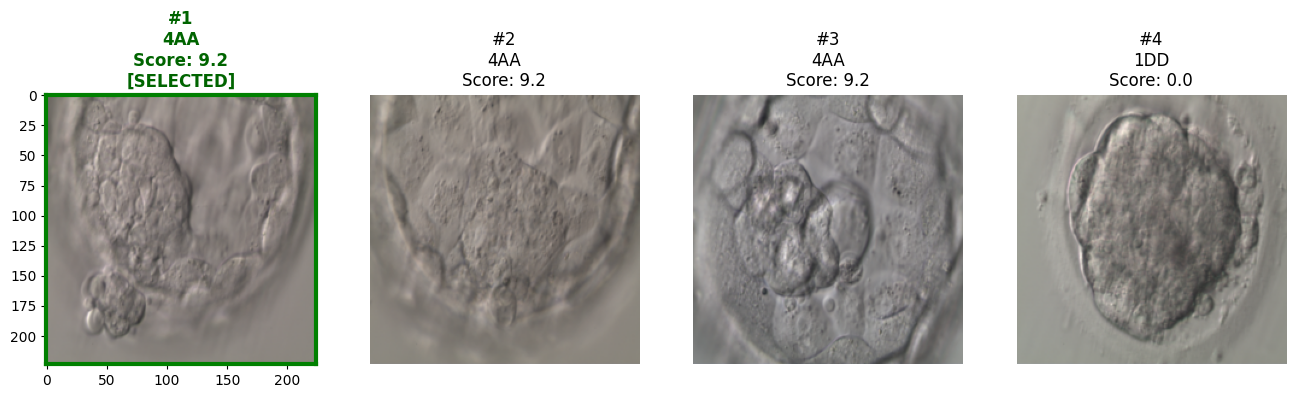

In [ ]:
# 7. Clinical Demo Support System

def get_embryo_score(exp, icm, te):
    mapping = {0: 10, 1: 6, 2: 2, 3: 0} # A=10, B=6, C=2, D=0
    score_icm = mapping.get(icm, 0)
    score_te = mapping.get(te, 0)
    score_exp = (exp / 5.0) * 10
    # Weighted Score
    return (score_icm * 0.45) + (score_te * 0.35) + (score_exp * 0.20)
def get_clinical_status(score):
    if score >= 8.5:
        return "Priority 1 (Transfer)", "High Viability"
    elif score >= 6.0:
        return "Priority 2 (Cryopreserve)", "Good Quality"
    else:
        return "Low Priority / Discard", "Poor Morphology"

def analyze_patient_cohort_diverse():
    # show variety
    data_iter = iter(dataloaders['val'])
    try:
        # Fetching only images, ignoring labels
        images, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloaders['val'])
        images, _ = next(data_iter)

    candidates = []
    model.eval()
    with torch.no_grad():
        for i, img in enumerate(images):
            if i >= 20: break # Scan up to 20 images to find good variance
            img_tensor = img.unsqueeze(0).to(device)
            o_exp, o_icm, o_te = model(img_tensor)
            p_exp = torch.argmax(o_exp, 1).item()
            p_icm = torch.argmax(o_icm, 1).item()
            p_te = torch.argmax(o_te, 1).item()
            score = get_embryo_score(p_exp, p_icm, p_te)
            # Mapping 0->A, 1->B..
            mapping = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
            # Add 1 to expansion because model predicts index 0-5 for grades 1-6
            grade = f"{p_exp+1}{mapping.get(p_icm, '?')}{mapping.get(p_te, '?')}"
            candidates.append({
                'img': img,
                'grade': grade,
                'score': score,
                'exp_idx': p_exp
            })

    # Select Diverse Embryos
    # Sort by score descending
    candidates.sort(key=lambda x: x['score'], reverse=True)
    if len(candidates) < 4:
        selected = candidates # Fallback if batch is small
    else:
        # Pick Top (Best), Middle (Average), Bottom (Worst), and Second Best
        selected = [
            candidates[0],                  # The best
            candidates[1],                  # The second best
            candidates[len(candidates)//2], # The Average
            candidates[-1]                  # The worse
        ]
    # assign IDs 1-4 for the report
    for idx, item in enumerate(selected):
        item['id'] = idx + 1

    # Report
    print(f"\n{'='*60}")
    print(f"Report:")
    print(f"{'='*60}")
    print(f"{'ID':<5} | {'GRADE':<8} | {'SCORE':<6} | {'RECOMMENDATION':<25}")
    print("-" * 60)
    best_embryo = selected[0]
    for res in selected:
        status, viability = get_clinical_status(res['score'])
        # Highlight the best row
        prefix = ">> " if res is best_embryo else "   "
        print(f"{prefix}{res['id']:<2} | {res['grade']:<8} | {res['score']:.1f}   | {status} ({viability})")

    print("-" * 60)
    print(f"CONCLUSION: Embryo #{best_embryo['id']} ({best_embryo['grade']}) selected for Single Embryo Transfer (SET).")
    print(f"{'='*60}\n")

    # Visualization
    fig, axes = plt.subplots(1, len(selected), figsize=(16, 5))
    for i, res in enumerate(selected):
        ax = axes[i]
        img_np = res['img'].cpu().permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        status, _ = get_clinical_status(res['score'])
        title = f"#{res['id']}\n{res['grade']}\nScore: {res['score']:.1f}"
        if res is best_embryo:
            ax.set_title(title + "\n[SELECTED]", fontweight='bold', color='darkgreen')
            # Add colored border
            for spine in ax.spines.values():
                spine.set_edgecolor('green')
                spine.set_linewidth(3)
        else:
            ax.set_title(title)
            ax.axis('off')

    plt.show()
analyze_patient_cohort_diverse()
analyze_patient_cohort_diverse()